# 02. Exploratory Data Analysis & Insights
**Project:** NTI Graduation Project <br>
**Dataset:** IBM HR Analytics Employee Attrition & Performance <br>
**Objective:** Analyze employee attrition patterns, identify high-risk employee segments, and generate data-driven insights to support HR retention strategies.

### 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'

### 2. Load Clean Data

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")

# Ensure Attrition_Num is strictly integer (1 for 'Yes', 0 for 'No')
df['Attrition_Num'] = df['Attrition'].astype(str).str.strip().str.lower().map({'yes': 1, '1': 1, 'no': 0, '0': 0}).fillna(0).astype(int)
df['Attrition_Status'] = df['Attrition_Num'].map({1: 'Left', 0: 'Stayed'})

# Standardize OverTime string representation cleanly
df['OverTime_Status'] = df['OverTime'].astype(str).str.strip().str.capitalize()
df['OverTime_Status'] = df['OverTime_Status'].replace({'1': 'Yes', '0': 'No', 'True': 'Yes', 'False': 'No'})

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Num,Attrition_Status,OverTime_Status
0,41.0,Yes,Travel_Rarely,1102.0,Sales,1.0,2,Life Sciences,2,Female,...,8.0,0,1,6.0,4.0,0.0,5.0,1,Left,Yes
1,49.0,No,Travel_Frequently,279.0,Research & Development,8.0,1,Life Sciences,3,Male,...,10.0,3,3,10.0,7.0,1.0,7.0,0,Stayed,No
2,37.0,Yes,Travel_Rarely,1373.0,Research & Development,2.0,2,Other,4,Male,...,7.0,3,3,0.0,0.0,0.0,0.0,1,Left,Yes
3,33.0,No,Travel_Frequently,1392.0,Research & Development,3.0,4,Life Sciences,4,Female,...,8.0,3,3,8.0,7.0,3.0,0.0,0,Stayed,Yes
4,27.0,No,Travel_Rarely,591.0,Research & Development,2.0,1,Medical,1,Male,...,6.0,3,3,2.0,2.0,2.0,2.0,0,Stayed,No


### 3. Analysis & Visualizations

#### 3.0 Overall Attrition Rate Exploration
*Matches SQL Query: `Q_Exploration: Understand overall attrition rate and how it varies across departments`*

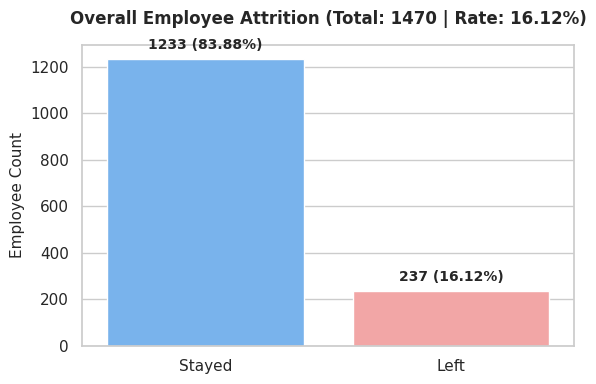

In [3]:
total_emps = len(df)
emps_left = df['Attrition_Num'].sum()
emps_stayed = total_emps - emps_left
overall_attrition_rate = (emps_left / total_emps * 100) if total_emps > 0 else 0.0

exploration_df = pd.DataFrame([{
    'Total_Emps': total_emps,
    'Emps_Left': emps_left,
    'Emps_Right': emps_stayed,
    'Attrition_Rate': round(overall_attrition_rate, 2)
}])

# Visual representation of Overall Attrition
plt.figure(figsize=(6, 4))
ax_exp = sns.barplot(x=['Stayed', 'Left'], y=[emps_stayed, emps_left], hue=['Stayed', 'Left'], palette=['#66b3ff', '#ff9999'], legend=False)
plt.title(f'Overall Employee Attrition (Total: {total_emps} | Rate: {overall_attrition_rate:.2f}%)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Employee Count', fontsize=11)

for p in ax_exp.patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        pct = (height / total_emps) * 100
        ax_exp.annotate(f"{int(height)} ({pct:.2f}%)", 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', xytext=(0, 5), 
                        textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.1 Attrition Rate by Department
*Matches SQL Query: `Q1.A: What is the attrition rate by department?`*

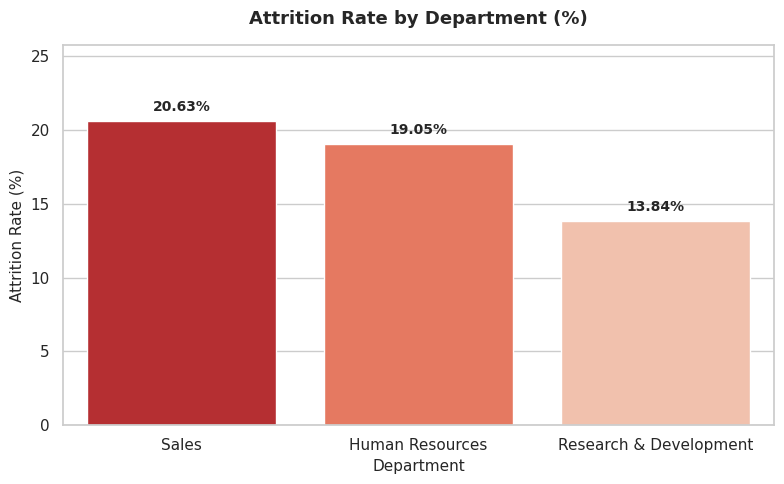

In [4]:
plt.figure(figsize=(8, 5))
dept_df = df.groupby('Department')['Attrition_Num'].agg(Total_Emps='count', Emps_Left='sum').reset_index()
dept_df['Attrition_Rate'] = np.where(dept_df['Total_Emps'] > 0, (dept_df['Emps_Left'] / dept_df['Total_Emps']) * 100, 0)
dept_df = dept_df.sort_values(by='Attrition_Rate', ascending=False)

ax1 = sns.barplot(data=dept_df, x='Department', y='Attrition_Rate', hue='Department', palette='Reds_r', legend=False)
plt.title('Attrition Rate by Department (%)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Attrition Rate (%)', fontsize=11)
plt.xlabel('Department', fontsize=11)

max_rate = dept_df['Attrition_Rate'].max() if not dept_df['Attrition_Rate'].empty else 100
plt.ylim(0, max_rate * 1.25 if max_rate > 0 else 100)

for p in ax1.patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        ax1.annotate(f"{height:.2f}%", 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', xytext=(0, 5), 
                     textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.2 Attrition Rate by Job Role
*Matches SQL Query: `Q1.B: What is the attrition rate by job role?`*

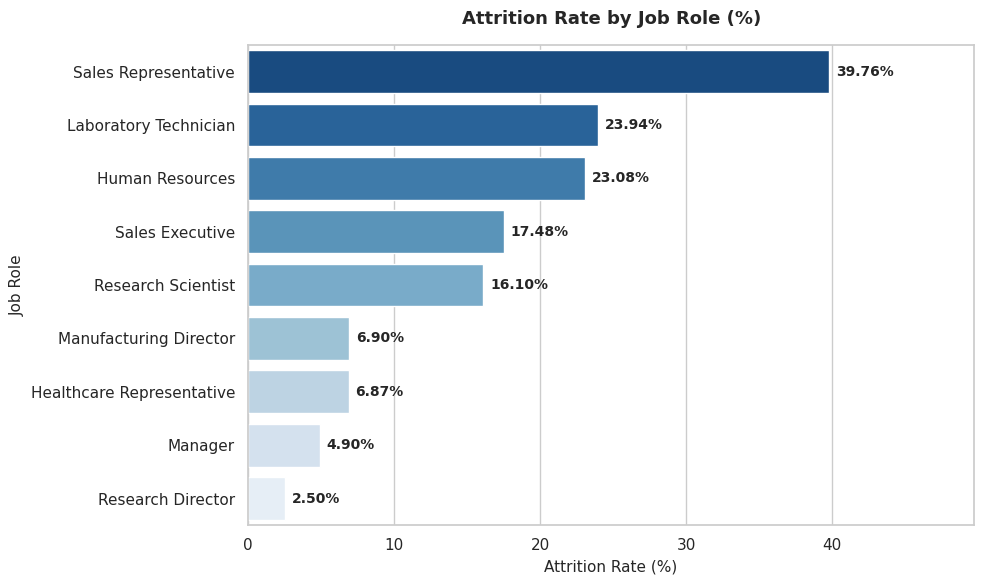

In [5]:
plt.figure(figsize=(10, 6))
role_df = df.groupby('JobRole')['Attrition_Num'].agg(Total_Emps='count', Emps_Left='sum').reset_index()
role_df['Attrition_Rate'] = np.where(role_df['Total_Emps'] > 0, (role_df['Emps_Left'] / role_df['Total_Emps']) * 100, 0)
role_df = role_df.sort_values(by='Attrition_Rate', ascending=False)

ax2 = sns.barplot(data=role_df, y='JobRole', x='Attrition_Rate', hue='JobRole', palette='Blues_r', legend=False)
plt.title('Attrition Rate by Job Role (%)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Attrition Rate (%)', fontsize=11)
plt.ylabel('Job Role', fontsize=11)

max_rate = role_df['Attrition_Rate'].max() if not role_df['Attrition_Rate'].empty else 100
plt.xlim(0, max_rate * 1.25 if max_rate > 0 else 100)

for p in ax2.patches:
    width = p.get_width()
    if pd.notna(width) and width > 0:
        ax2.annotate(f"{width:.2f}%", 
                     (width, p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', xytext=(5, 0), 
                     textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.3 Attrition Rate by Overtime Status
*Matches SQL Query: `Q1.C & Diagnostic Q2: Cross-tabulate overtime status against attrition`*

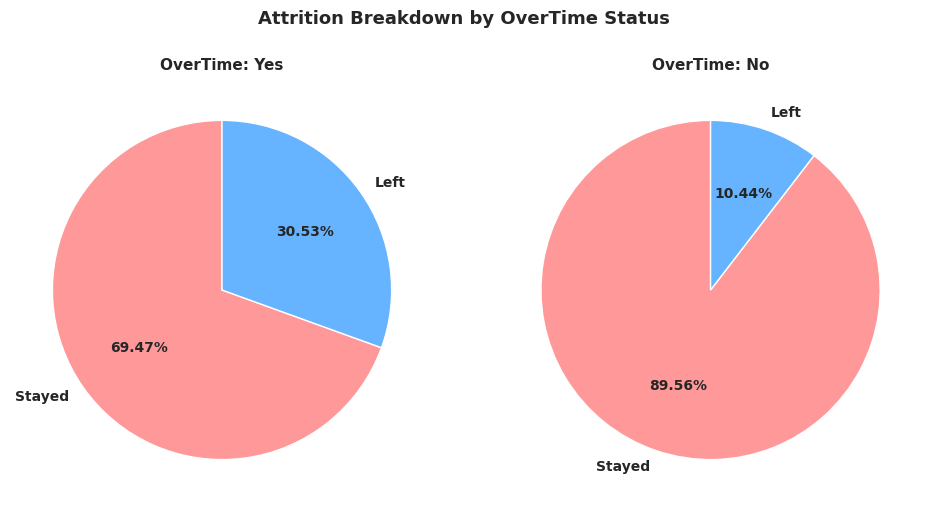

In [6]:
ot_summary = df.groupby('OverTime_Status')['Attrition_Num'].agg(Total_Emps='count', Emps_Left='sum').reset_index()
ot_summary['Emps_Right'] = ot_summary['Total_Emps'] - ot_summary['Emps_Left']
ot_summary['Attrition_Rate'] = np.where(ot_summary['Total_Emps'] > 0, (ot_summary['Emps_Left'] / ot_summary['Total_Emps']) * 100, 0)
ot_summary = ot_summary.sort_values(by='Attrition_Rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, status in enumerate(['Yes', 'No']):
    sub_df = df[df['OverTime_Status'] == status]
    counts = sub_df['Attrition_Status'].value_counts()
    
    if not counts.empty:
        axes[i].pie(
            counts, 
            labels=counts.index, 
            autopct='%1.2f%%', 
            startangle=90, 
            colors=['#ff9999', '#66b3ff'],
            textprops={'fontsize': 10, 'weight': 'bold'}
        )
    axes[i].set_title(f'OverTime: {status}', fontsize=11, fontweight='bold')

plt.suptitle('Attrition Breakdown by OverTime Status', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 3.4 Average Monthly Income by Job Level & Attrition Status
*Matches SQL Query: `Q2: Average monthly income by job level and attrition status`*

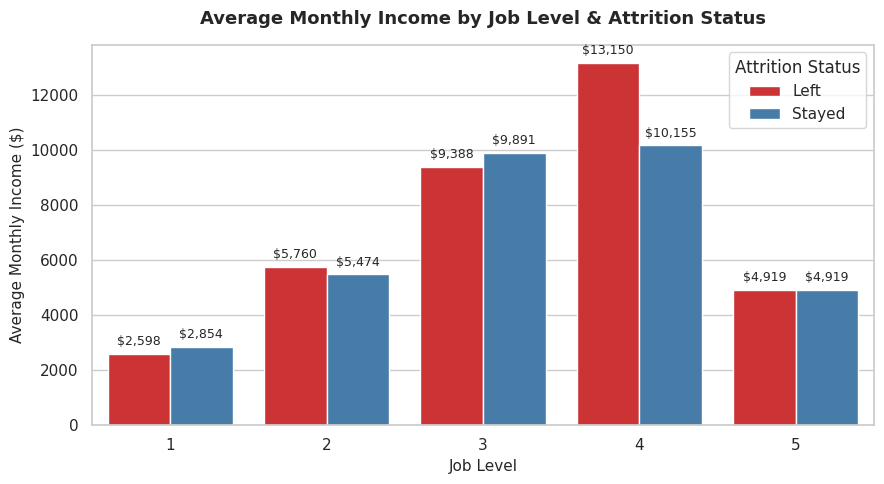

In [7]:
income_summary = df.groupby(['JobLevel', 'Attrition_Status'])['MonthlyIncome'].mean().reset_index()
income_summary.rename(columns={'MonthlyIncome': 'Avg_MonthlyIncome'}, inplace=True)
income_summary['Avg_MonthlyIncome'] = income_summary['Avg_MonthlyIncome'].round(2)
income_summary = income_summary.sort_values(by=['JobLevel', 'Attrition_Status'])

plt.figure(figsize=(9, 5))
ax4 = sns.barplot(data=income_summary, x='JobLevel', y='Avg_MonthlyIncome', hue='Attrition_Status', palette='Set1')
plt.title('Average Monthly Income by Job Level & Attrition Status', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Average Monthly Income ($)', fontsize=11)
plt.xlabel('Job Level', fontsize=11)
plt.legend(title='Attrition Status')

for p in ax4.patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        ax4.annotate(f"${height:,.0f}", 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', xytext=(0, 4), 
                     textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

#### 3.5 Attrition Rate for Low Job Satisfaction Employees on Overtime
*Matches SQL Query: `Q3: Which employees combine low job satisfaction with frequent overtime?`*

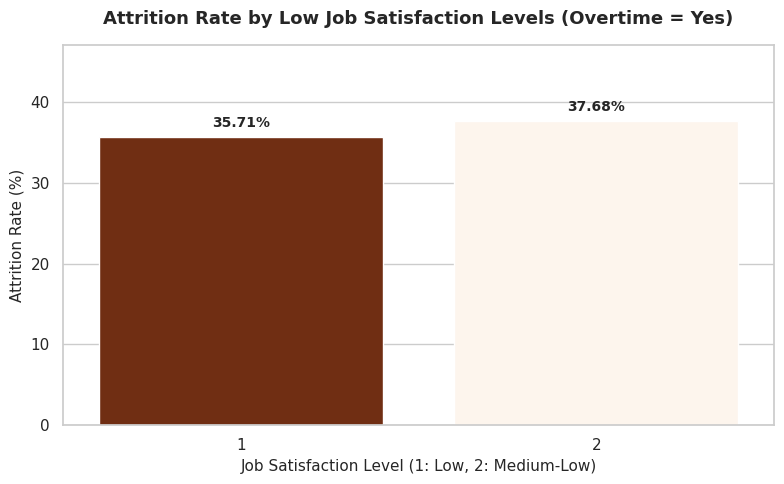

In [8]:
plt.figure(figsize=(8, 5))

# 1. Filter and aggregate matching the exact SQL query logic
q3_df = df[(df['JobSatisfaction'] <= 2) & (df['OverTime_Status'] == 'Yes')].groupby(['JobSatisfaction', 'OverTime_Status'])['Attrition_Num'].agg(
    Total_Emps='count',
    Emps_left='sum'
).reset_index()

# 2. Calculate Attrition Rate
q3_df['AttritionRate'] = np.where(q3_df['Total_Emps'] > 0, (q3_df['Emps_left'] / q3_df['Total_Emps']) * 100, 0.0)
q3_df['AttritionRate'] = q3_df['AttritionRate'].round(2)
q3_df = q3_df.sort_values(by='JobSatisfaction')

# 3. Barplot Visualization by JobSatisfaction Level (1 vs 2)
ax5 = sns.barplot(
    data=q3_df, 
    x='JobSatisfaction', 
    y='AttritionRate', 
    hue='JobSatisfaction', 
    palette='Oranges_r', 
    legend=False
)

plt.title('Attrition Rate by Low Job Satisfaction Levels (Overtime = Yes)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Attrition Rate (%)', fontsize=11)
plt.xlabel('Job Satisfaction Level (1: Low, 2: Medium-Low)', fontsize=11)

max_rate = q3_df['AttritionRate'].max() if not q3_df['AttritionRate'].empty else 100
plt.ylim(0, max_rate * 1.25 if max_rate > 0 else 100)

for p in ax5.patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        ax5.annotate(f"{height:.2f}%", 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', xytext=(0, 5), 
                     textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.6 Highest Attrition Department & Sales Role Breakdown
*Matches SQL Query: `Q4.A: Highest attrition department` & `Q4.B / Diagnostic Q4: Drill into Sales job roles`*

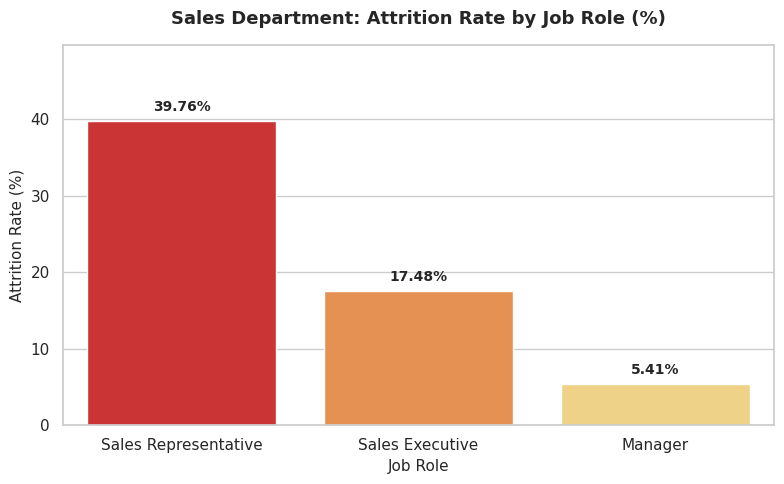

In [9]:
# Q4.A: Find Highest Attrition Department
top_dept_df = df.groupby('Department')['Attrition_Num'].agg(Total='count', Left='sum').reset_index()
top_dept_df['AttritionRate'] = np.where(top_dept_df['Total'] > 0, (top_dept_df['Left'] / top_dept_df['Total']) * 100, 0)
top_dept_df = top_dept_df.sort_values(by='AttritionRate', ascending=False).head(1)

# Q4.B / Diagnostic Q4: Drill down into Sales Department
sales_df = df[df['Department'] == 'Sales'].groupby('JobRole')['Attrition_Num'].agg(Total='count', Left='sum').reset_index()
sales_df['AttritionRate'] = np.where(sales_df['Total'] > 0, (sales_df['Left'] / sales_df['Total']) * 100, 0.0)
sales_df = sales_df.sort_values(by='AttritionRate', ascending=False)

plt.figure(figsize=(8, 5))
ax6 = sns.barplot(data=sales_df, x='JobRole', y='AttritionRate', hue='JobRole', palette='YlOrRd_r', legend=False)
plt.title('Sales Department: Attrition Rate by Job Role (%)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Attrition Rate (%)', fontsize=11)
plt.xlabel('Job Role', fontsize=11)

max_rate = sales_df['AttritionRate'].max() if not sales_df['AttritionRate'].empty else 100
plt.ylim(0, max_rate * 1.25 if max_rate > 0 else 100)

for p in ax6.patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        ax6.annotate(f"{height:.2f}%", 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', xytext=(0, 5), 
                     textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.7 Attrition Rate by Tenure Group (YearsAtCompany)
*Matches SQL Query: `Diagnostic Q1: Bucket 'YearsAtCompany' into tenure groups`*

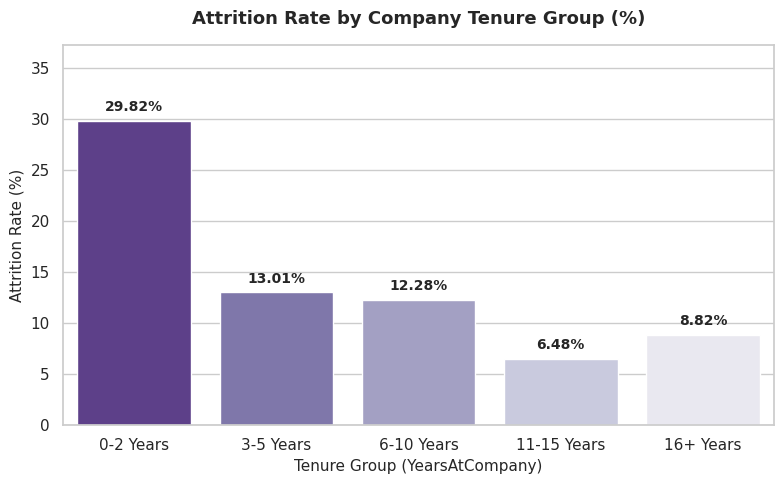

In [10]:
def tenure_bucket(years):
    if years <= 2: return '0-2 Years'
    elif years <= 5: return '3-5 Years'
    elif years <= 10: return '6-10 Years'
    elif years <= 15: return '11-15 Years'
    else: return '16+ Years'

df['TenureGroup'] = df['YearsAtCompany'].apply(tenure_bucket)
tenure_order = ['0-2 Years', '3-5 Years', '6-10 Years', '11-15 Years', '16+ Years']
tenure_df = df.groupby('TenureGroup')['Attrition_Num'].agg(Total='count', Left='sum').reindex(tenure_order).dropna(how='all').reset_index()
tenure_df['AttritionRate'] = np.where(tenure_df['Total'] > 0, (tenure_df['Left'] / tenure_df['Total']) * 100, 0)

plt.figure(figsize=(8, 5))
ax7 = sns.barplot(data=tenure_df, x='TenureGroup', y='AttritionRate', hue='TenureGroup', palette='Purples_r', legend=False)
plt.title('Attrition Rate by Company Tenure Group (%)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Attrition Rate (%)', fontsize=11)
plt.xlabel('Tenure Group (YearsAtCompany)', fontsize=11)

max_rate = tenure_df['AttritionRate'].max() if not tenure_df['AttritionRate'].empty else 100
plt.ylim(0, max_rate * 1.25 if max_rate > 0 else 100)

for p in ax7.patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        ax7.annotate(f"{height:.2f}%", 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha='center', va='bottom', xytext=(0, 5), 
                     textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.8 Diagnostic Metrics: Leavers vs. Stayers
*Matches SQL Query: `Diagnostic Q3: Compare average income, job satisfaction, and work-life balance`*

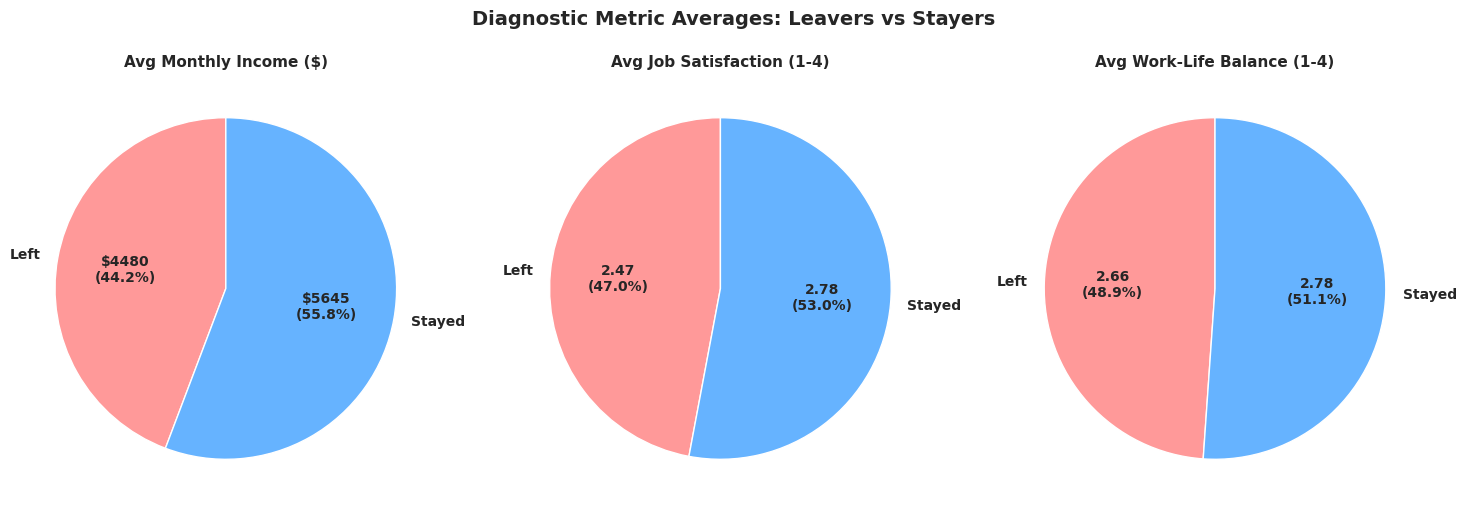

In [11]:
diag_summary = df.groupby('Attrition_Status')[['MonthlyIncome', 'JobSatisfaction', 'WorkLifeBalance']].mean().reset_index()
diag_summary.rename(columns={
    'MonthlyIncome': 'Avg_Income',
    'JobSatisfaction': 'Avg_Satisfaction',
    'WorkLifeBalance': 'Avg_WorkLife_Balance'
}, inplace=True)
diag_summary['Avg_Income'] = diag_summary['Avg_Income'].round(2)
diag_summary['Avg_Satisfaction'] = diag_summary['Avg_Satisfaction'].round(2)
diag_summary['Avg_WorkLife_Balance'] = diag_summary['Avg_WorkLife_Balance'].round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
diag_summary_plot = diag_summary.set_index('Attrition_Status')
metrics = ['Avg_Income', 'Avg_Satisfaction', 'Avg_WorkLife_Balance']
titles = ['Avg Monthly Income ($)', 'Avg Job Satisfaction (1-4)', 'Avg Work-Life Balance (1-4)']
fmts = ['${:.0f}', '{:.2f}', '{:.2f}']
colors = ['#ff9999', '#66b3ff']

for i, col in enumerate(metrics):
    data = diag_summary_plot[col]
    fmt = fmts[i]
    
    def make_autopct(values, format_str):
        def my_autopct(pct):
            total = sum(values)
            val = pct * total / 100
            return f"{format_str.format(val)}\n({pct:.1f}%)"
        return my_autopct

    axes[i].pie(
        data, 
        labels=data.index, 
        autopct=make_autopct(data, fmt),
        startangle=90, 
        colors=colors,
        textprops={'fontsize': 10, 'weight': 'bold'}
    )
    axes[i].set_title(titles[i], fontweight='bold', fontsize=11)

plt.suptitle('Diagnostic Metric Averages: Leavers vs Stayers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4. Summary & Findings

In [12]:
# 1. Re-calculate overall attrition rate
overall_attrition = (df['Attrition_Num'].sum() / len(df)) * 100 if len(df) > 0 else 0

# 2. Re-calculate top department
dept_df = df.groupby('Department')['Attrition_Num'].agg(Total='count', Left='sum').reset_index()
dept_df['AttritionRate'] = np.where(dept_df['Total'] > 0, (dept_df['Left'] / dept_df['Total']) * 100, 0)
dept_df = dept_df.sort_values(by='AttritionRate', ascending=False)
top_dept = dept_df.iloc[0] if not dept_df.empty else {'Department': 'N/A', 'AttritionRate': 0}

# 3. Explicitly define ot_df
ot_df = df.groupby('OverTime_Status')['Attrition_Num'].agg(Total='count', Left='sum').reset_index()
ot_df['AttritionRate'] = np.where(ot_df['Total'] > 0, (ot_df['Left'] / ot_df['Total']) * 100, 0)

# 4. Safe lookup function for filtered rates
def safe_get_rate(dataframe, col_name, match_val, rate_col='AttritionRate'):
    filtered = dataframe[dataframe[col_name].astype(str).str.strip().str.lower() == str(match_val).lower()]
    return filtered[rate_col].values[0] if not filtered.empty else 0.0

ot_rate = safe_get_rate(ot_df, 'OverTime_Status', 'Yes')
no_ot_rate = safe_get_rate(ot_df, 'OverTime_Status', 'No')
early_tenure_rate = safe_get_rate(tenure_df, 'TenureGroup', '0-2 Years')

# Output Executive Summary
print("EXECUTIVE SUMMARY & KEY FINDINGS")
print("--------------------------------")
print(f"- Overall Organizational Attrition Rate : {overall_attrition:.2f}%")
print(f"- Highest Turnover Department           : {top_dept['Department']} ({top_dept['AttritionRate']:.2f}%)")
print(f"- Overtime Risk Multiplier              : {ot_rate:.2f}% (Overtime) vs {no_ot_rate:.2f}% (No Overtime)")
print(f"- Early Career Turnover Hazard          : {early_tenure_rate:.2f}% (0-2 YearsAtCompany)")

EXECUTIVE SUMMARY & KEY FINDINGS
--------------------------------
- Overall Organizational Attrition Rate : 16.12%
- Highest Turnover Department           : Sales (20.63%)
- Overtime Risk Multiplier              : 30.53% (Overtime) vs 10.44% (No Overtime)
- Early Career Turnover Hazard          : 29.82% (0-2 YearsAtCompany)
